# Observatoire WIW Camargue 
## I. Recherche STAC (Earth Search) et lecture des bandes sur la zone d'intérêt (AOI)

Ce notebook permet de :
1. Charger la zone d'intérêt (limite de la Camargue) et la reprojeter pour la recherche STAC
2. Rechercher sur Earth Search trois scènes Sentinel-2 L2A, une par an, sur la même fenêtre saisonnière, avec un faible taux de nuages
3. Lire et découper les bandes nécessaires au calcul de l'indice WIW ( Water In Wetlands) (NIR, SWIR2, SCL) sur l'AOI, avec reprojection automatique
4. Visualiser les bandes brutes pour vérifier la cohérence des données avant le calcul de l'indice

### Dépendances

```
pip install geopandas pystac-client rasterio matplotlib shapely
```


In [1]:
import os

# Permet à GDAL/rasterio de lire les COG publics sur S3 sans credentials AWS,
# et évite un listing de répertoire coûteux à chaque ouverture
os.environ["AWS_NO_SIGN_REQUEST"] = "YES"
os.environ["GDAL_DISABLE_READDIR_ON_OPEN"] = "EMPTY_DIR"

import geopandas as gpd
import pystac_client 
import rasterio
from rasterio.mask import mask
import matplotlib.pyplot as plt
import numpy as np
import shapely.geometry
import shapely.ops


## 1. Chargement de la zone d'intérêt (AOI)

On charge le shapefile de la Camargue, on note son CRS d'origine, puis on le reprojette
en WGS84 (EPSG:4326) : c'est le système a priori attendu pour la bbox de recherche STAC.
La géométrie d'origine sera réutilisée plus loin, reprojetée dans le CRS natif
de chaque image (UTM) pour le découpage.

CRS d'origine : EPSG:4326
Nombre d'entités : 1
Bbox WGS84 : [4.230213234693098, 43.32871527690241, 4.91723448884928, 43.70498530067309]


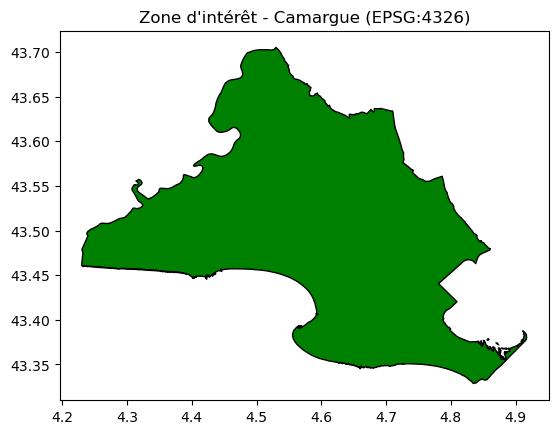

In [2]:
AOI_PATH = "/home/khalil/workspaces/wiw-camargue/pipeline/aoi/limite_camargue.gpkg"  # à adapter

aoi = gpd.read_file(AOI_PATH)
print(f"CRS d'origine : {aoi.crs}")
print(f"Nombre d'entités : {len(aoi)}")

# Reprojection en WGS84 pour la recherche STAC (bbox attendue en lon/lat)
aoi_wgs84 = aoi.to_crs("EPSG:4326") if aoi.crs != "EPSG:4326" else aoi
bbox = aoi_wgs84.total_bounds.tolist()
print(f"Bbox WGS84 : {bbox}")


aoi_wgs84.plot(edgecolor="black", facecolor="green")
plt.title("Zone d'intérêt - Camargue (EPSG:4326)")
plt.show()


## 2. Recherche STAC sur Earth Search (Sentinel-2 L2A)

On interroge le catalogue STAC public d'Earth Search (Element84, pas d'authentification).
Pour chaque année, on cherche sur une même fenêtre saisonnière (printemps) afin de rendre
la comparaison interannuelle pertinente, et on filtre sur la couverture nuageuse pour ne
garder que des scènes exploitables.

> Note d'architecture : `CATALOG_URL` et `COLLECTION` sont les seuls éléments propres
> à Earth Search. Le reste du code (recherche, filtrage) fonctionnerait de la même
> façon avec un autre catalogue STAC conforme, par exemple le Copernicus Data Space
> Ecosystem (DIAS officiel), en ajoutant la gestion de l'authentification OAuth2.

In [3]:
CATALOG_URL = "https://earth-search.aws.element84.com/v1"
COLLECTION = "sentinel-2-l2a"

client = pystac_client.Client.open(CATALOG_URL)

# Une fenêtre de recherche par an, même saison (printemps)
date_ranges = [
    "2024-04-01/2024-05-31",
    "2025-04-01/2025-05-31",
    "2026-04-01/2026-05-31",
]

MAX_CLOUD_COVER = 15  # %
MIN_AOI_COVERAGE = 0.98  # on veut au moins 98% de la surface de l'AOI couverte

# Géométrie unique de l'AOI (utile pour calculer les taux de couverture)
aoi_geom_wgs84 = aoi_wgs84.unary_union
aoi_area = aoi_geom_wgs84.area


def select_minimal_tiles(items, target_coverage):
    """Sélectionne le NOMBRE MINIMAL de tuiles nécessaires pour couvrir l'AOI
    à hauteur de `target_coverage`, en triant par nébulosité croissante.

    On trie les tuiles par nébulosité croissante puis on les ajoute une à une,
    en ne gardant que celles qui apportent une vraie plus-value de couverture,
    et on s'arrête dès que la cible est atteinte.
    """
    candidates = [
        (item, shapely.geometry.shape(item.geometry))
        for item in items
    ]
    # On ne garde que les tuiles qui touchent réellement l'AOI
    candidates = [(i, g) for i, g in candidates if g.intersects(aoi_geom_wgs84)]
    candidates.sort(key=lambda c: c[0].properties["eo:cloud_cover"])

    selected = []
    covered = None
    current_coverage = 0.0

    for item, geom in candidates:
        if current_coverage >= target_coverage:
            break
        new_covered = geom if covered is None else shapely.ops.unary_union([covered, geom])
        new_coverage = new_covered.intersection(aoi_geom_wgs84).area / aoi_area
        if new_coverage > current_coverage:  # la tuile apporte une vraie plus-value
            selected.append(item)
            covered = new_covered
            current_coverage = new_coverage

    return selected, current_coverage


# Pour chaque date, on garde une LISTE de tuiles (1, 2 ou 3 selon le cas) :
# le strict nécessaire pour couvrir l'AOI, pas toutes les tuiles disponibles.
selected_items = {}

for date_range in date_ranges:
    search = client.search(
        collections=[COLLECTION],
        bbox=bbox,
        datetime=date_range,
        query={"eo:cloud_cover": {"lt": MAX_CLOUD_COVER}},
    )
    items = list(search.items())

    if not items:
        print(f"{date_range} -> aucune scène trouvée sous {MAX_CLOUD_COVER}% de nuages")
        continue

    # On regroupe par date d'acquisition exacte : un même jour peut nécessiter
    # plusieurs tuiles adjacentes pour couvrir toute l'AOI.
    by_acq_date = {}
    for item in items:
        by_acq_date.setdefault(item.datetime.date(), []).append(item)

    # Pour chaque date d'acquisition candidate, on sélectionne le minimum de
    # tuiles nécessaires, puis on compare les dates entre elles.
    candidates = []
    for acq_date, day_items in by_acq_date.items():
        chosen_tiles, coverage = select_minimal_tiles(day_items, MIN_AOI_COVERAGE)
        if not chosen_tiles:
            continue
        mean_cloud = sum(i.properties["eo:cloud_cover"] for i in chosen_tiles) / len(chosen_tiles)
        candidates.append((coverage, mean_cloud, acq_date, chosen_tiles))

    if not candidates:
        print(f"{date_range} -> aucune tuile ne touche réellement l'AOI")
        continue

    # On garde la date qui couvre le mieux l'AOI (et en cas d'égalité, la moins nuageuse)
    candidates.sort(key=lambda c: (-c[0], c[1]))
    best_coverage, best_cloud, best_date, best_items = candidates[0]

    selected_items[date_range] = best_items

    tile_ids = ", ".join(i.id for i in best_items)
    print(
        f"{date_range} -> {len(best_items)} tuile(s) le {best_date} "
        f"(couverture AOI: {best_coverage:.1%}, nuages moyens: {best_cloud:.1f}%) "
        f"- {tile_ids}"
    )
    if best_coverage < MIN_AOI_COVERAGE:
        print(f"  /!\\ Couverture incomplète de l'AOI pour {date_range} ({best_coverage:.1%})")


/tmp/ipykernel_24213/468103272.py:17: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  aoi_geom_wgs84 = aoi_wgs84.unary_union


2024-04-01/2024-05-31 -> 3 tuile(s) le 2024-04-21 (couverture AOI: 100.0%, nuages moyens: 0.0%) - S2B_31TFH_20240421_0_L2A, S2B_31TEJ_20240421_0_L2A, S2B_31TFJ_20240421_0_L2A
2025-04-01/2025-05-31 -> 3 tuile(s) le 2025-04-30 (couverture AOI: 100.0%, nuages moyens: 0.8%) - S2A_31TFH_20250430_0_L2A, S2A_31TEJ_20250430_0_L2A, S2A_31TFJ_20250430_0_L2A
2026-04-01/2026-05-31 -> 3 tuile(s) le 2026-04-15 (couverture AOI: 100.0%, nuages moyens: 0.1%) - S2A_31TEJ_20260415_0_L2A, S2A_31TFH_20260415_0_L2A, S2A_31TFJ_20260415_0_L2A


## 3. Lecture et découpage des bandes (NIR, SWIR2, SCL)

Pour chaque scène sélectionnée, on lit trois bandes nécessaires au calcul du WIW :

- `nir` (B08, 10 m) : proche infrarouge
- `swir22` (B12, 20 m) : infrarouge à ondes courtes
- `scl` (20 m) : Scene Classification Layer, utilisée pour le masque de nuages

Chaque asset est un COG accessible directement par HTTP. La fonction ci-dessous
reprojette l'AOI dans le CRS natif de l'image (UTM) avant de découper - c'est la
reprojection faite plus haut.

Le problème d'avoir des tuiles avec des crs différents ne se posent pas vu que la Camargue est entièrement en zone 31N



In [4]:
from rasterio.io import MemoryFile
from rasterio.merge import merge


def read_band_mosaic_clipped(asset_hrefs, aoi_gdf):
    """Lit un ou plusieurs assets COG (une tuile ou plusieurs tuiles pour la
    même date), les mosaïque si besoin, puis découpe le résultat sur l'AOI
    (reprojection automatique vers le CRS du raster)."""
    datasets = [rasterio.open(href) for href in asset_hrefs]
    try:
        src_crs = datasets[0].crs
        aoi_proj = aoi_gdf.to_crs(src_crs)
        # On limite la mosaïque à l'emprise de l'AOI : évite de télécharger
        # l'intégralité de chaque tuile (110x110 km) via le réseau.
        bounds = tuple(aoi_proj.total_bounds)

        mosaic, mosaic_transform = merge(datasets, bounds=bounds)

        profile = datasets[0].profile.copy()
        profile.update(
            height=mosaic.shape[1],
            width=mosaic.shape[2],
            transform=mosaic_transform,
            count=1,
        )

        with MemoryFile() as memfile:
            with memfile.open(**profile) as mem_dataset:
                mem_dataset.write(mosaic)
                out_image, out_transform = mask(mem_dataset, aoi_proj.geometry, crop=True)
                return out_image[0], out_transform, mem_dataset.crs
    finally:
        for ds in datasets:
            ds.close()


# Bandes d'intérêt pour le calcul du WIW
BANDS = {"nir": "nir", "swir2": "swir22", "scl": "scl"}

bands_by_date = {}

for date_range, items in selected_items.items():
    bands = {}
    crs_used = None
    for band_key, asset_key in BANDS.items():
        hrefs = [item.assets[asset_key].href for item in items]
        data, transform, crs = read_band_mosaic_clipped(hrefs, aoi_wgs84)
        bands[band_key] = data
        crs_used = crs
        bands[f"{band_key}_transform"] = transform
        bands[f"{band_key}_crs"] = crs
    bands_by_date[date_range] = bands

    tile_ids = ", ".join(item.id for item in items)
    print(
        f"{date_range} - CRS: {crs_used} - {len(items)} tuile(s) ({tile_ids}) - "
        f"NIR {bands['nir'].shape}, SWIR2 {bands['swir2'].shape}, SCL {bands['scl'].shape}"
    )


2024-04-01/2024-05-31 - CRS: EPSG:32631 - 3 tuile(s) (S2B_31TFH_20240421_0_L2A, S2B_31TEJ_20240421_0_L2A, S2B_31TFJ_20240421_0_L2A) - NIR (4129, 5580), SWIR2 (2065, 2790), SCL (2065, 2790)
2025-04-01/2025-05-31 - CRS: EPSG:32631 - 3 tuile(s) (S2A_31TFH_20250430_0_L2A, S2A_31TEJ_20250430_0_L2A, S2A_31TFJ_20250430_0_L2A) - NIR (4129, 5580), SWIR2 (2065, 2790), SCL (2065, 2790)
2026-04-01/2026-05-31 - CRS: EPSG:32631 - 3 tuile(s) (S2A_31TEJ_20260415_0_L2A, S2A_31TFH_20260415_0_L2A, S2A_31TFJ_20260415_0_L2A) - NIR (4129, 5580), SWIR2 (2065, 2790), SCL (2065, 2790)


## 4. Visualisation des bandes brutes

Une grille avec une ligne par date et une colonne par bande, pour vérifier
visuellement la cohérence des données (absence de nuages résiduels, emprise
correcte) avant de passer au calcul du WIW.

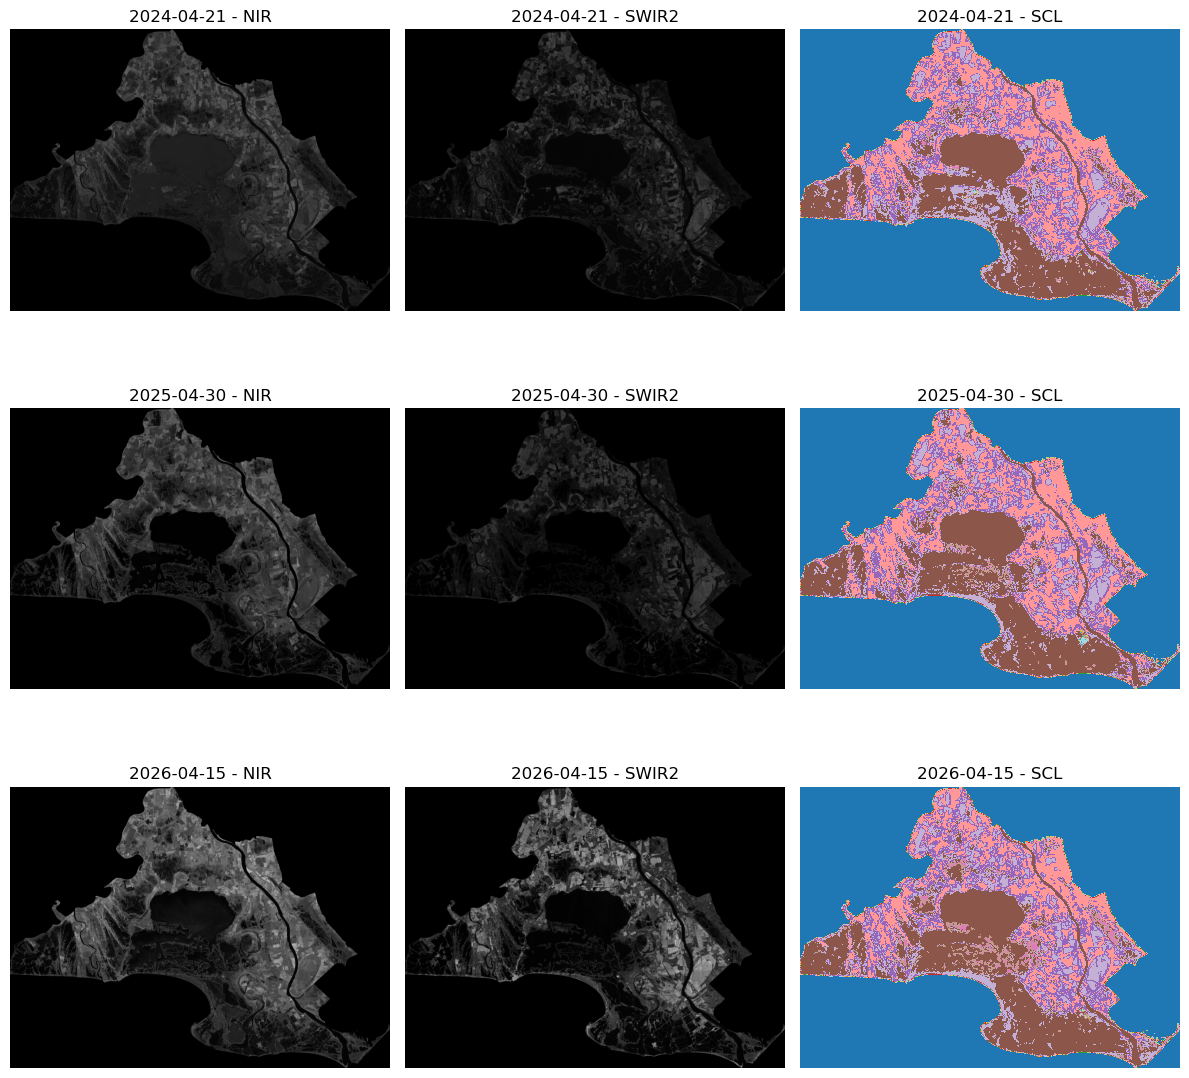

In [5]:
n_dates = len(bands_by_date)
fig, axes = plt.subplots(n_dates, 3, figsize=(12, 4 * n_dates))

if n_dates == 1:
    axes = axes.reshape(1, -1)

for row, (date_range, bands) in enumerate(bands_by_date.items()):
    items = selected_items[date_range]
    date_str = items[0].datetime.date()  # toutes les tuiles d'un même groupe partagent la date
    for col, (band_name, cmap) in enumerate([("nir", "gray"), ("swir2", "gray"), ("scl", "tab20")]):
        ax = axes[row, col]
        ax.imshow(bands[band_name], cmap=cmap)
        ax.set_title(f"{date_str} - {band_name.upper()}")
        ax.axis("off")

plt.tight_layout()
plt.show()


## II. Calcul de l'indice WIW

Application de la règle WIW (Lefebvre et al., 2019) sur les bandes NIR et SWIR2,
combinée au masque de qualité dérivé de la bande SCL (nuages, ombres, neige,
no data). Les seuils ci-dessous correspondent aux valeurs Sentinel-2 publiées
par les auteurs (réflectance de surface, ~94% de précision globale).

### Calul WIW

In [7]:
from rasterio.warp import reproject, Resampling

# Seuils de réflectance de surface (Sentinel-2), Lefebvre et al. 2019
NIR_THRESHOLD_S2 = 0.1804
SWIR2_THRESHOLD_S2 = 0.1131

# Classes SCL exclues : no data, saturé/défectueux, ombre de nuage,
# nuage proba moyenne, nuage proba haute, cirrus fin, neige
SCL_INVALID_CLASSES = {0, 1, 3, 8, 9, 10, 11}

# Facteur d'échelle des réflectances Sentinel-2 L2A (DN -> [0, 1])
S2_REFLECTANCE_SCALE = 10000.0


def resample_to_reference(src_array, src_transform, src_crs,
                           ref_array, ref_transform, ref_crs,
                           resampling=Resampling.bilinear):
    """Réechantillonne src_array sur la grille (forme + transform) de ref_array."""
    dst = np.empty(ref_array.shape, dtype=src_array.dtype)
    reproject(
        source=src_array,
        destination=dst,
        src_transform=src_transform,
        src_crs=src_crs,
        dst_transform=ref_transform,
        dst_crs=ref_crs,
        resampling=resampling,
    )
    return dst


def compute_wiw(nir, nir_transform, nir_crs,
                swir2, swir2_transform, swir2_crs,
                scl, scl_transform, scl_crs,
                nir_threshold=NIR_THRESHOLD_S2,
                swir2_threshold=SWIR2_THRESHOLD_S2):
    """
    Calcule le masque WIW sur la grille NIR (10 m).
    Retourne : water_mask (1=eau, 0=non-eau, 255=invalide), transform associé.
    """
    swir2_10m = resample_to_reference(
        swir2, swir2_transform, swir2_crs,
        nir, nir_transform, nir_crs,
        resampling=Resampling.bilinear,
    )
    scl_10m = resample_to_reference(
        scl, scl_transform, scl_crs,
        nir, nir_transform, nir_crs,
        resampling=Resampling.nearest,
    )

    nir_refl = nir.astype("float32") / S2_REFLECTANCE_SCALE
    swir2_refl = swir2_10m.astype("float32") / S2_REFLECTANCE_SCALE

    valid_mask = ~np.isin(scl_10m, list(SCL_INVALID_CLASSES))
    is_water = (nir_refl <= nir_threshold) & (swir2_refl <= swir2_threshold)

    water_mask = np.where(valid_mask, is_water.astype("uint8"), 255).astype("uint8")
    return water_mask, nir_transform


def water_area_ha(water_mask, transform):
    """Surface en eau (ha) à partir du masque WIW et de la résolution du transform."""
    pixel_area_m2 = abs(transform.a * transform.e)
    n_water_pixels = int(np.sum(water_mask == 1))
    return n_water_pixels * pixel_area_m2 / 10_000

In [8]:
results = {}

for date_range, items in selected_items.items():
    b = bands_by_date[date_range]

    water_mask, mask_transform = compute_wiw(
        b["nir"], b["nir_transform"], b["nir_crs"],
        b["swir2"], b["swir2_transform"], b["swir2_crs"],
        b["scl"], b["scl_transform"], b["scl_crs"],
    )

    area_ha = water_area_ha(water_mask, mask_transform)
    # `items` est une liste (1, 2 ou 3 tuiles) ; elles partagent toutes la
    # même date d'acquisition (c'est le critère de regroupement de la cellule 6)
    acq_date = items[0].datetime.date()
    tile_ids = [item.id for item in items]

    results[date_range] = {
        "mask": water_mask,
        "transform": mask_transform,
        "crs": b["nir_crs"],
        "area_ha": area_ha,
        "items": items,
        "date": acq_date,
        "tile_ids": tile_ids,
    }
    print(f"{acq_date} : surface en eau estimée = {area_ha:.1f} ha ({len(items)} tuile(s))")

2024-04-21 : surface en eau estimée = 30447.0 ha (3 tuile(s))
2025-04-30 : surface en eau estimée = 43507.0 ha (3 tuile(s))
2026-04-15 : surface en eau estimée = 45841.3 ha (3 tuile(s))


### Visualisation des masques WIW (3 dates)

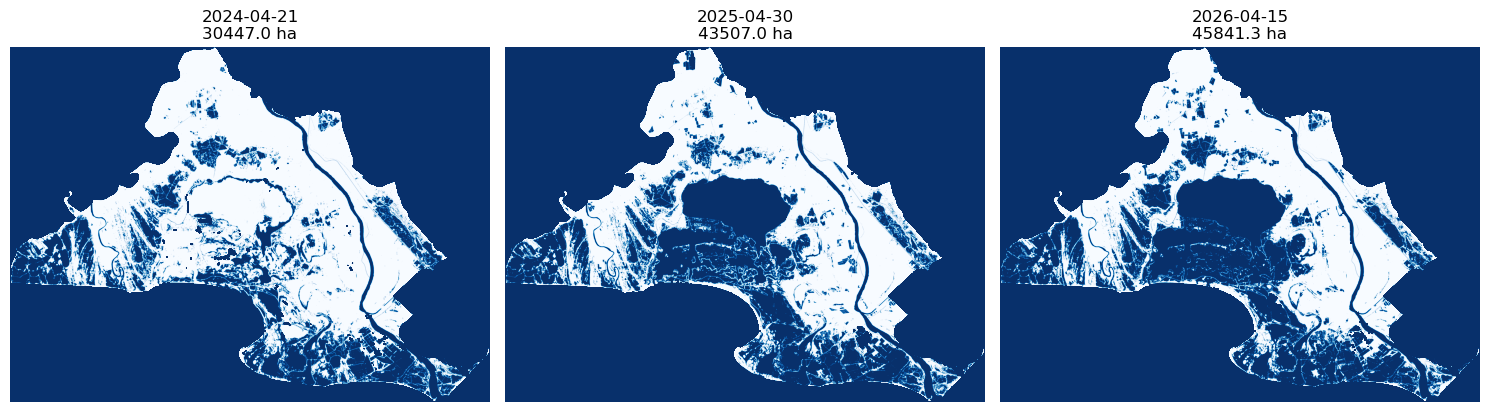

In [9]:
fig, axes = plt.subplots(1, len(results), figsize=(5 * len(results), 5))
if len(results) == 1:
    axes = [axes]

for ax, (date_range, r) in zip(axes, results.items()):
    ax.imshow(r["mask"], cmap="Blues", vmin=0, vmax=1)
    ax.set_title(f"{r['date']}\n{r['area_ha']:.1f} ha")
    ax.axis("off")

plt.tight_layout()
plt.show()

## III. Vectorisation et export multi-formats

Chaque masque WIW est exporté en COG, vectorisé en polygones "eau", puis
écrit dans trois formats : GeoJSON (web/Leaflet), GeoPackage (SIG desktop),
GeoParquet (cloud-natif). Les fichiers sont rangés par date dans `catalogue/`,
en préparation du catalogue STAC 

In [10]:
import os
from rasterio.features import shapes
from shapely.geometry import shape


def export_mask_to_cog(water_mask, transform, crs, output_path):
    """Exporte le masque WIW en GeoTIFF Cloud-Optimized (tiled + overviews)."""
    profile = {
        "driver": "GTiff",
        "height": water_mask.shape[0],
        "width": water_mask.shape[1],
        "count": 1,
        "dtype": "uint8",
        "crs": crs,
        "transform": transform,
        "nodata": 255,
        "tiled": True,
        "blockxsize": 256,
        "blockysize": 256,
        "compress": "deflate",
    }
    with rasterio.open(output_path, "w", **profile) as dst:
        dst.write(water_mask, 1)
        dst.build_overviews([2, 4, 8, 16], rasterio.enums.Resampling.nearest)
    return output_path


def vectorize_water_mask(water_mask, transform, crs, item_id=None, item_date=None):
    """Vectorise les pixels "eau" (valeur 1) en polygones. Ignore nuages/non-eau."""
    water_only = np.where(water_mask == 1, 1, 0).astype("uint8")

    polygons = [
        shape(geom)
        for geom, value in shapes(water_only, mask=water_only == 1, transform=transform)
        if value == 1
    ]

    if not polygons:
        return gpd.GeoDataFrame({"area_ha": [], "item_id": [], "date": []}, geometry=[], crs=crs)

    gdf = gpd.GeoDataFrame(geometry=polygons, crs=crs)
    gdf["area_ha"] = gdf.geometry.area / 10_000
    gdf["item_id"] = item_id
    gdf["date"] = item_date
    return gdf


def write_vector_formats(gdf, output_basepath):
    """Écrit le GeoDataFrame en GeoJSON (WGS84), GeoPackage et GeoParquet (CRS natif)."""
    geojson_path = f"{output_basepath}.geojson"
    gpkg_path = f"{output_basepath}.gpkg"
    parquet_path = f"{output_basepath}.parquet"

    gdf.to_crs("EPSG:4326").to_file(geojson_path, driver="GeoJSON")
    gdf.to_file(gpkg_path, driver="GPKG")
    gdf.to_parquet(parquet_path)

    return {"geojson": geojson_path, "gpkg": gpkg_path, "parquet": parquet_path}

In [13]:
vector_results = {}

for date_range, r in results.items():
    year = r["date"].year
    out_dir = f"/home/khalil/workspaces/wiw-camargue/catalogue/wiw-{year}"
    os.makedirs(out_dir, exist_ok=True)

    export_mask_to_cog(r["mask"], r["transform"], r["crs"], f"{out_dir}/wiw-{year}.tif")

    gdf = vectorize_water_mask(
        r["mask"], r["transform"], r["crs"],
        item_id=", ".join(r["tile_ids"]),  # toutes les tuiles utilisées, séparées par virgule
        item_date=r["date"].isoformat(),
    )
    write_vector_formats(gdf, f"{out_dir}/wiw-{year}")

    vector_results[date_range] = gdf
    print(f"{year} : {len(gdf)} polygones, {gdf['area_ha'].sum():.1f} ha -> {out_dir}/")

2024 : 17494 polygones, 30447.0 ha -> /home/khalil/workspaces/wiw-camargue/catalogue/wiw-2024/
2025 : 14270 polygones, 43507.0 ha -> /home/khalil/workspaces/wiw-camargue/catalogue/wiw-2025/
2026 : 11697 polygones, 45841.3 ha -> /home/khalil/workspaces/wiw-camargue/catalogue/wiw-2026/


## IV. Évolution de la surface en eau (3 ans)

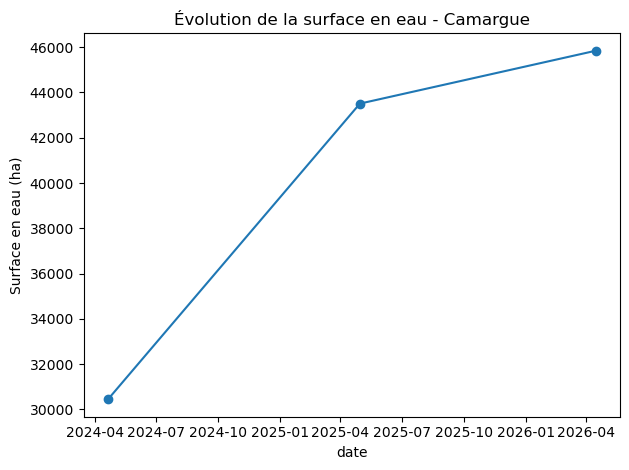

,date,surface_ha
0,2024-04-21,30447.02
1,2025-04-30,43507.00
2,2026-04-15,45841.28


In [14]:
import pandas as pd

summary = pd.DataFrame([
    {"date": r["date"], "surface_ha": r["area_ha"]}
    for r in results.values()
]).sort_values("date")

os.makedirs("figures", exist_ok=True)
summary.plot(x="date", y="surface_ha", marker="o", legend=False)
plt.ylabel("Surface en eau (ha)")
plt.title("Évolution de la surface en eau - Camargue")
plt.tight_layout()
plt.savefig("figures/evolution_surface_eau.png", dpi=150)
plt.show()

summary